## 1. Imports
Loading the libraries needed for data handling, visualization, scaling, dimensionality reduction, clustering, and classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report

## 2. Data Loading
Reading the country socio-economic dataset and the accompanying data dictionary to understand what each column represents.

In [2]:
df = pd.read_csv('../utils/week3/Country-data.csv')

In [3]:
print(df.columns)
print(df.info())

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [4]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Duplicate rows: 0


In [6]:
data_dict = pd.read_csv('../utils/week3/data-dictionary.csv')

In [7]:
print(data_dict)

  Column Name                                        Description
0     country                                Name of the country
1  child_mort  Death of children under 5 years of age per 100...
2     exports  Exports of goods and services per capita. Give...
3      health  Total health spending per capita. Given as %ag...
4     imports  Imports of goods and services per capita. Give...
5      Income                              Net income per person
6   Inflation  The measurement of the annual growth rate of t...
7  life_expec  The average number of years a new born child w...
8   total_fer  The number of children that would be born to e...
9        gdpp  The GDP per capita. Calculated as the Total GD...


## 3. Data Preprocessing
`exports`, `health`, and `imports` are given as percentages of GDP per capita, so they are converted to absolute values for easier interpretation. Outliers in skewed columns are capped, and features are scaled before clustering.

In [8]:
df['exports'] = (df['exports'] / 100) * df['gdpp']
df['health'] = (df['health'] / 100) * df['gdpp']
df['imports'] = (df['imports'] / 100) * df['gdpp']

## 4. Exploratory Data Analysis
Checking distributions, correlations, and outliers across all socio-economic and health indicators before modeling.

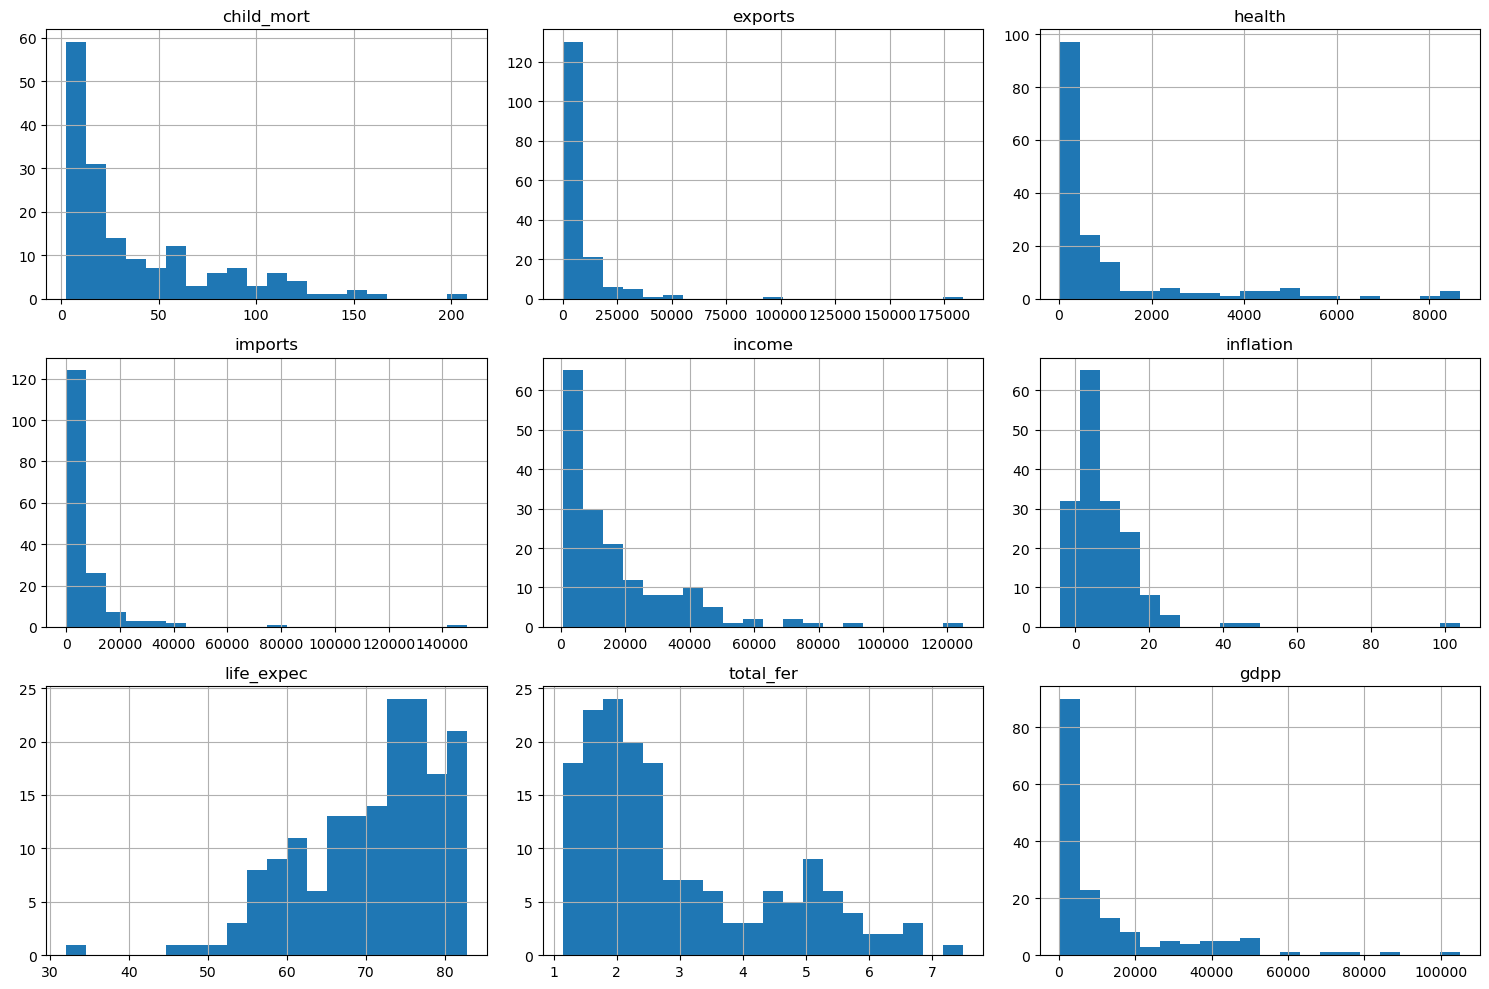

In [9]:
# checking distributions and skewness
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

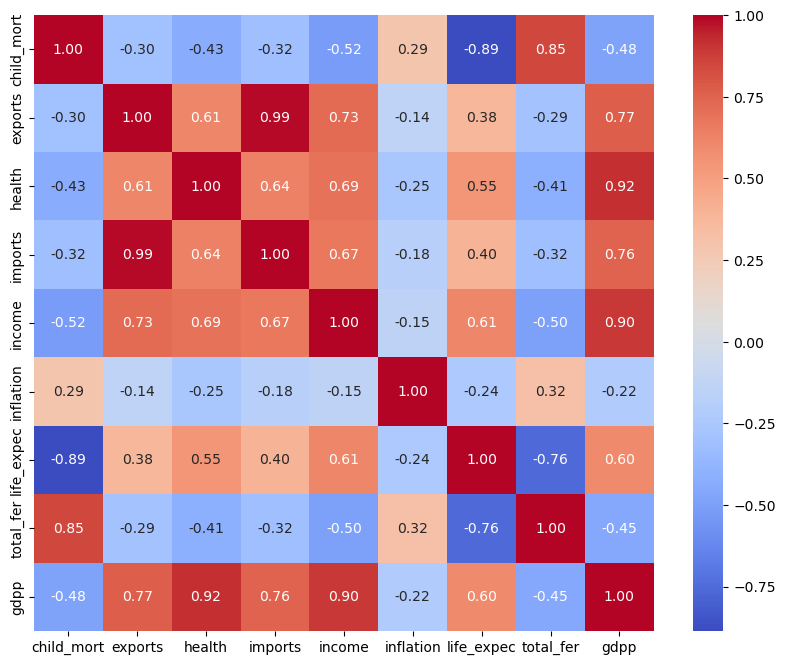

In [10]:
# checking correlations between features
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['country']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

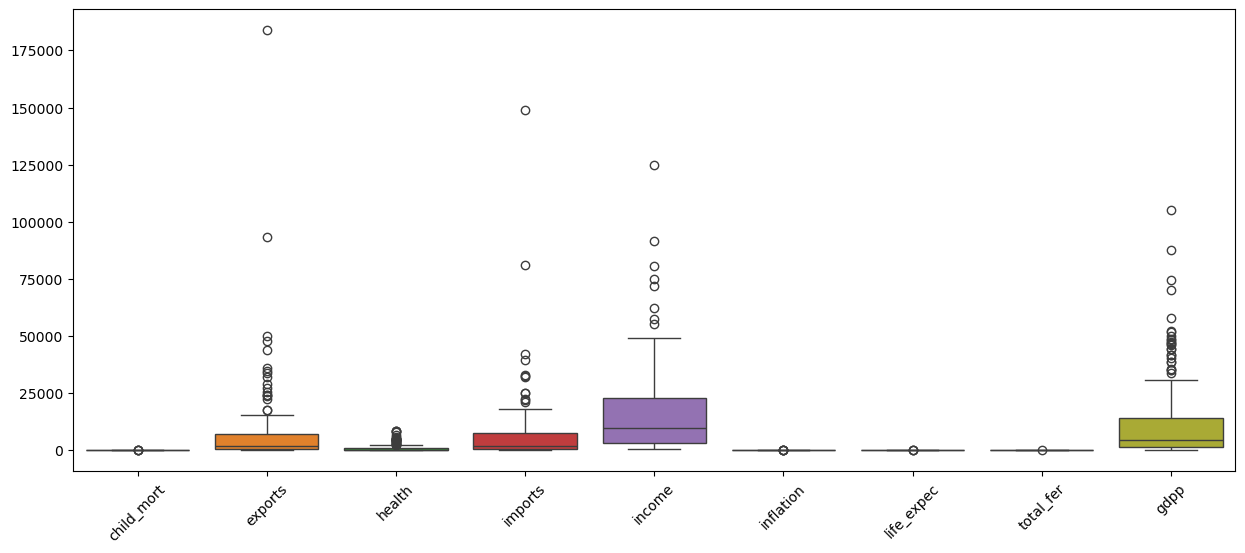

In [11]:
# checking outliers visually using boxplots
plt.figure(figsize=(15, 6))
sns.boxplot(data=df.drop(columns=['country']))
plt.xticks(rotation=45)
plt.show()

In [12]:
# treating extreme outliers
cols_to_cap = ['income', 'gdpp', 'exports', 'imports', 'health']
for col in cols_to_cap:
    percentile_95 = df[col].quantile(0.95)
    df[col] = np.where(df[col] > percentile_95, percentile_95, df[col])

# separating names and scaling features
country_names = df['country']
numeric_features = df.drop(columns=['country'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

## 5. Dimensionality Reduction (PCA)
Reducing the scaled features to two principal components, used only for visualizing clusters, not for the clustering itself.

In [13]:
# applying pca
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# creating a dataframe for the pca components
df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.66721126 0.15091192]


In [14]:
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## 6. K-Means Clustering
Finding the optimal number of clusters using the elbow method and silhouette score, then fitting the final K-Means model.

In [15]:
# finding optimal k for k-means using elbow and silhouette scores
inertia_list = []
silhouette_list = []
k_range = range(2, 6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(scaled_features, labels))

  File "C:\Users\sharm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\sharm\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sharm\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sharm\anaconda3\Lib\subprocess.

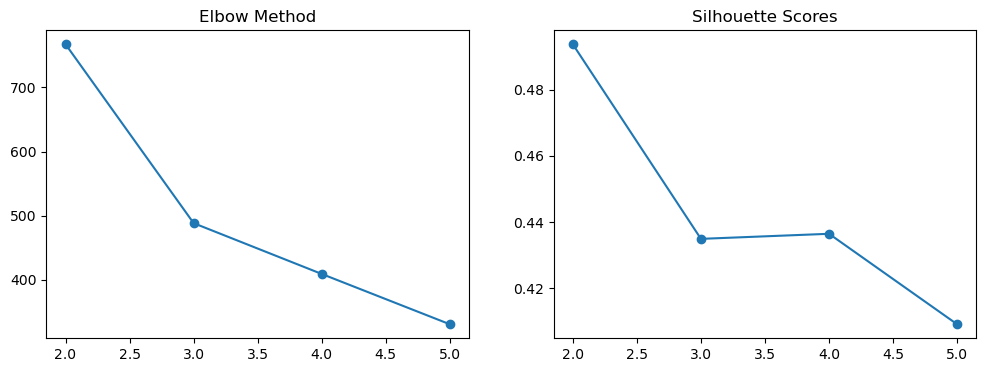

In [16]:
# plotting elbow and silhouette results
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertia_list, marker='o')
ax[0].set_title('Elbow Method')
ax[1].plot(k_range, silhouette_list, marker='o')
ax[1].set_title('Silhouette Scores')
plt.show()

## 7. Hierarchical Clustering
Building a dendrogram as a second clustering method to cross-check the number of natural groupings in the data.

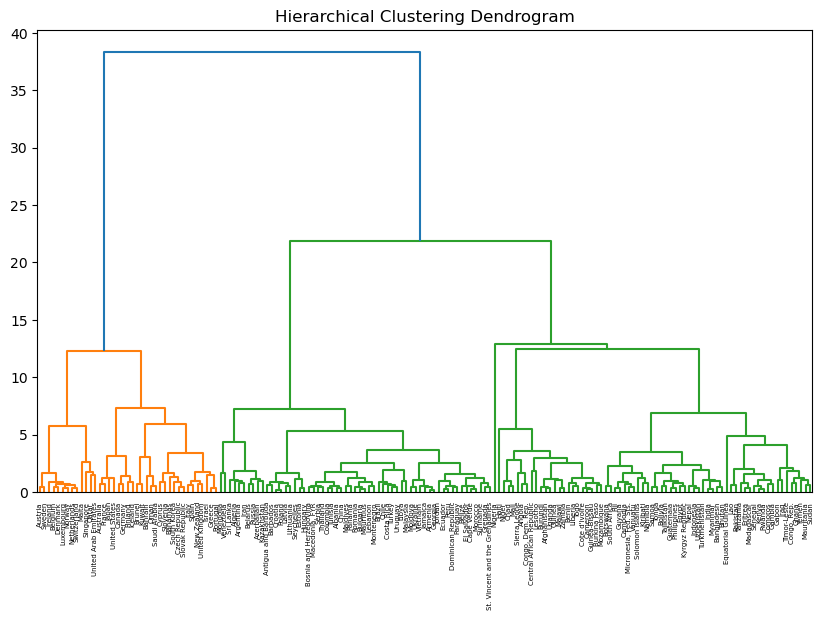

In [17]:
# generating a hierarchical clustering dendrogram
plt.figure(figsize=(10, 6))
linkage_matrix = linkage(scaled_features, method='ward')
dendrogram(linkage_matrix, labels=country_names.values, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

## 8. DBSCAN Clustering
DBSCAN groups countries by density instead of distance to a centroid. The k-distance plot is used to pick `eps`, then DBSCAN is run and compared against K-Means.

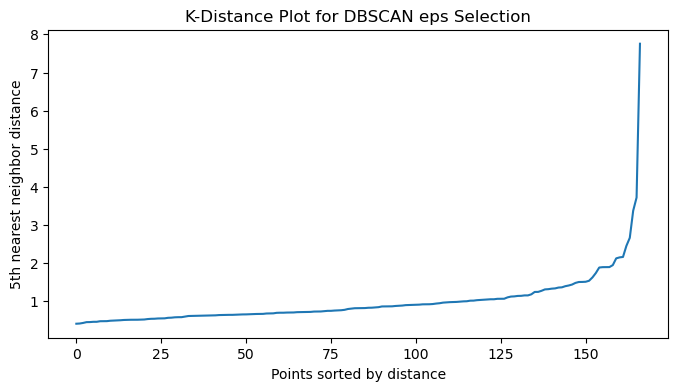

In [18]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
distances, _ = neighbors.fit(scaled_features).kneighbors(scaled_features)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Plot for DBSCAN eps Selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.show()

In [19]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_features)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points")
print(df['dbscan_cluster'].value_counts())

DBSCAN found 1 clusters and 12 noise points
dbscan_cluster
 0    155
-1     12
Name: count, dtype: int64


In [20]:
# applying optimal k-means based on evaluation results
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = final_kmeans.fit_predict(scaled_features)
df_pca['cluster'] = df['cluster']

In [29]:
dbscan_summary = df.groupby('dbscan_cluster')[['child_mort', 'income', 'gdpp']].mean()
print("DBSCAN cluster profile:\n", dbscan_summary)
print(f"\nDBSCAN produced {n_clusters} meaningful cluster(s) with {n_noise} points labeled as noise, "
      f"compared to K-Means' 3 well-separated groups. K-Means is used going forward since it better "
      f"matches the expected 3-tier development structure (developed / developing / under-developed).")

DBSCAN cluster profile:
                 child_mort        income          gdpp
dbscan_cluster                                        
-1               53.366667  28057.500000  21876.833333
 0               37.101290  14785.051613  11234.077419

DBSCAN produced 1 meaningful cluster(s) with 12 points labeled as noise, compared to K-Means' 3 well-separated groups. K-Means is used going forward since it better matches the expected 3-tier development structure (developed / developing / under-developed).


## 9. Cluster Profiling and Country Ranking
Profiling each K-Means cluster by average child mortality, income, GDP per capita, and life expectancy to identify which cluster represents the least developed countries.

Cluster Profiles:
          child_mort        income          gdpp  life_expec
cluster                                                    
0         22.860000  12317.529412   6278.847059   72.464706
1          5.237838  38711.081081  37745.675676   79.956757
2         94.537778   3312.733333   1633.600000   59.220000

Cluster label mapping: {np.int32(1): 'Developed', np.int32(0): 'Developing', np.int32(2): 'Under-developed'}


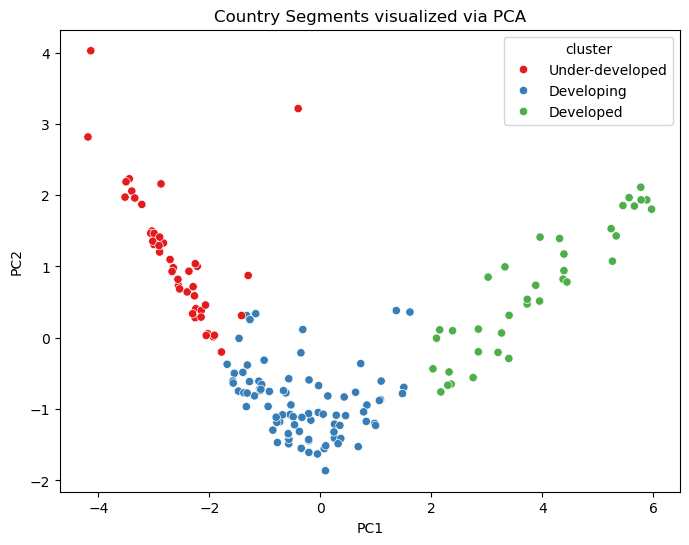

In [21]:
cluster_profile = df.groupby('cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()
print("Cluster Profiles:\n", cluster_profile)

development_rank = cluster_profile['gdpp'].sort_values(ascending=False).index
cluster_labels = {development_rank[0]: 'Developed', development_rank[1]: 'Developing', development_rank[2]: 'Under-developed'}
print("\nCluster label mapping:", cluster_labels)

df['development_status'] = df['cluster'].map(cluster_labels)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue=df['cluster'].map(cluster_labels), data=df_pca, palette='Set1')
plt.title('Country Segments visualized via PCA')
plt.show()

## 10. Classification: Validating the Clusters
Since clustering produces no ground-truth labels, Random Forest and XGBoost are trained on the cluster assignments themselves. This checks whether the clusters are separable and reveals which features drive the grouping.

In [23]:
# splitting features and using our cluster labels as ground truth
X_train, X_test, y_train, y_test = train_test_split(scaled_features, df['cluster'], test_size=0.3, random_state=42)

In [24]:
# comparing models: random forest vs xgboost
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train, y_train)

print("Random Forest Results:\n", classification_report(y_test, rf_clf.predict(X_test)))
print("XGBoost Results:\n", classification_report(y_test, xgb_clf.predict(X_test)))

Random Forest Results:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        29
           1       1.00      1.00      1.00        11
           2       1.00      0.82      0.90        11

    accuracy                           0.96        51
   macro avg       0.98      0.94      0.96        51
weighted avg       0.96      0.96      0.96        51

XGBoost Results:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      1.00      1.00        11
           2       1.00      0.91      0.95        11

    accuracy                           0.98        51
   macro avg       0.99      0.97      0.98        51
weighted avg       0.98      0.98      0.98        51



In [25]:
# extracting feature importances from random forest to explain factors
importances = rf_clf.feature_importances_
feature_names = numeric_features.columns
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

C:\Users\sharm\AppData\Local\Temp\ipykernel_24152\3165366122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


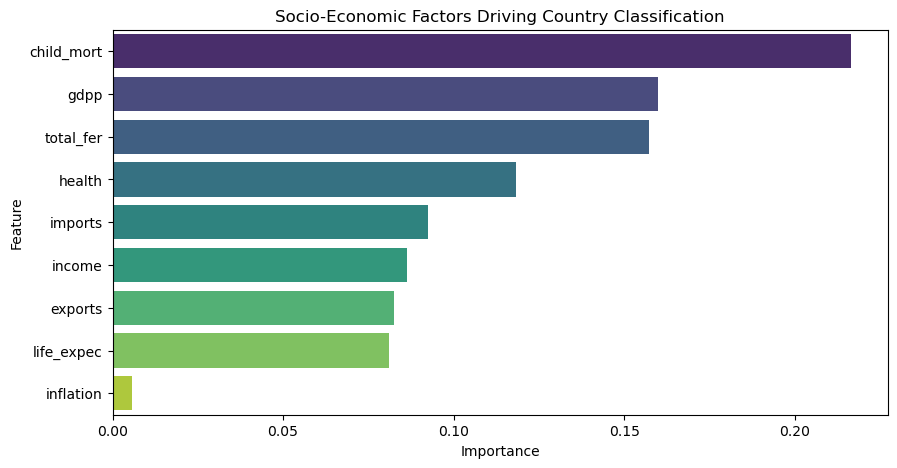

In [26]:
# plotting what factors drove countries into their respective clusters
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Socio-Economic Factors Driving Country Classification')
plt.show()

## 11. Conclusion: Countries Needing Aid
Final list of countries recommended to HELP International's CEO, ranked by child mortality and lowest GDP per capita within the under-developed cluster.

In [27]:
priority_countries = df[df['development_status'] == 'Under-developed']
ranked_need = priority_countries.sort_values(by=['child_mort', 'gdpp'], ascending=[False, True])

print(f"Total countries in direst need: {len(ranked_need)}")
print("\nTop 15 countries recommended for aid:")
print(ranked_need[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].head(15).to_string(index=False))

Total countries in direst need: 45

Top 15 countries recommended for aid:
                 country  child_mort  income    gdpp  life_expec
                   Haiti       208.0  1500.0   662.0        32.1
            Sierra Leone       160.0  1220.0   399.0        55.0
                    Chad       150.0  1930.0   897.0        56.5
Central African Republic       149.0   888.0   446.0        47.5
                    Mali       137.0  1870.0   708.0        59.5
                 Nigeria       130.0  5150.0  2330.0        60.5
                   Niger       123.0   814.0   348.0        58.8
                  Angola       119.0  5900.0  3530.0        60.1
        Congo, Dem. Rep.       116.0   609.0   334.0        57.5
            Burkina Faso       116.0  1430.0   575.0        57.9
           Guinea-Bissau       114.0  1390.0   547.0        55.6
                   Benin       111.0  1820.0   758.0        61.8
           Cote d'Ivoire       111.0  2690.0  1220.0        56.3
       Equatoria

C:\Users\sharm\AppData\Local\Temp\ipykernel_24152\2945050044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='child_mort', y='country', data=ranked_need.head(10), palette='Reds_r')


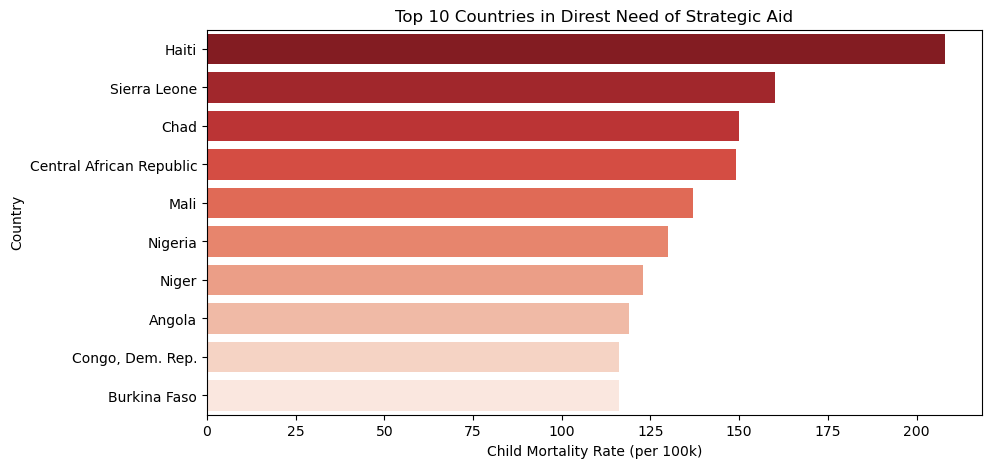

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(x='child_mort', y='country', data=ranked_need.head(10), palette='Reds_r')
plt.title('Top 10 Countries in Direst Need of Strategic Aid')
plt.xlabel('Child Mortality Rate (per 100k)')
plt.ylabel('Country')
plt.show()